# Projet Time Series — Monthly Sales of French Champagne

**Problème 2 : Monthly Sales of French Champagne**  
Ce notebook suit la structure demandée dans l'énoncé du projet : analyse exploratoire, préparation, stationnarité, transformations, identification ACF/PACF, modélisation, évaluation, diagnostic des résidus et conclusion.

**Objectif :** construire et comparer plusieurs modèles de prévision pour une série mensuelle représentant les ventes de champagne en France.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import shapiro

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. Chargement et présentation de la série

La série étudiée contient deux colonnes :

- `Month` : date mensuelle de l'observation ;
- `Sales` : nombre de ventes de champagne pour le mois correspondant.

Comme il s'agit d'une série temporelle mensuelle, nous transformons la colonne `Month` en index temporel avec une fréquence mensuelle de début de mois (`MS`).


In [2]:
# Le fichier doit se trouver dans le même dossier que le notebook, dans ../data/ ou dans /mnt/data lors de l'exécution sur ChatGPT.
possible_paths = [
    Path("champagne.csv"),
    Path("../data/champagne.csv"),
    Path("/mnt/data/champagne.csv")
]

csv_path = None
for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError("Placez le fichier champagne.csv dans le même dossier que ce notebook ou dans un dossier data/.")

raw_df = pd.read_csv(csv_path)
raw_df.head()


,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


In [3]:
df = raw_df.copy()

# Conversion de la colonne Month en date puis définition comme index temporel.
df["Month"] = pd.to_datetime(df["Month"])
df = df.set_index("Month").sort_index()

# On force la fréquence mensuelle de début de mois.
# Cela permet à pandas/statsmodels d'identifier explicitement la périodicité mensuelle.
df = df.asfreq("MS")

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105 entries, 1964-01-01 to 1972-09-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   105 non-null    int64
dtypes: int64(1)
memory usage: 1.6 KB


In [4]:
df.head(), df.tail(), df.shape

(            Sales
 Month            
 1964-01-01   2815
 1964-02-01   2672
 1964-03-01   2755
 1964-04-01   2721
 1964-05-01   2946,
             Sales
 Month            
 1972-05-01   4618
 1972-06-01   5312
 1972-07-01   4298
 1972-08-01   1413
 1972-09-01   5877,
 (105, 1))

### Commentaire initial

Chaque observation correspond à un mois. La variable étudiée est le nombre de ventes mensuelles de champagne en France. Comme les valeurs sont des volumes de ventes, l'unité d'interprétation des erreurs sera aussi le **nombre de ventes par mois**.


## 2. Analyse exploratoire

L'objectif de l'analyse exploratoire est de comprendre la dynamique générale de la série avant de modéliser.

Nous allons étudier :

- l'évolution temporelle ;
- les statistiques descriptives ;
- la tendance ;
- la variance ;
- la saisonnalité potentielle ;
- les valeurs atypiques éventuelles.

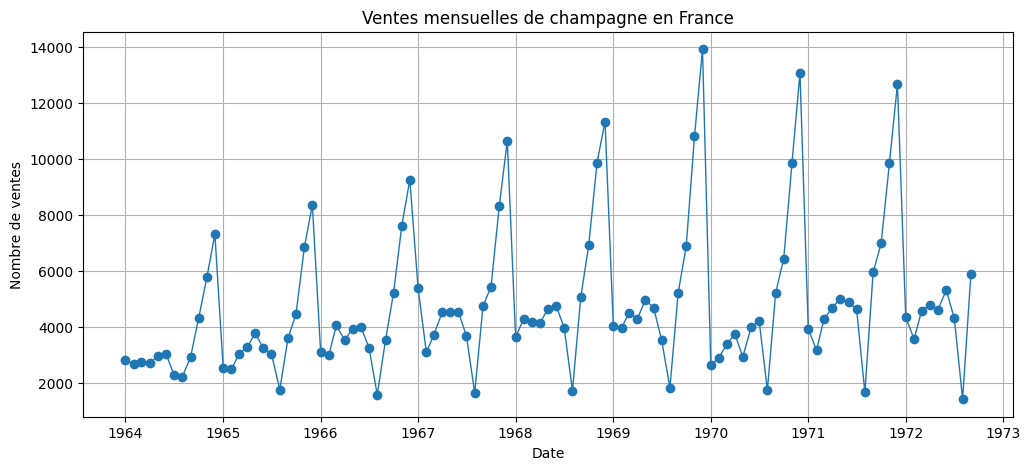

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Sales"], marker="o", linewidth=1)
ax.set_title("Ventes mensuelles de champagne en France")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de ventes")
plt.show()


### Statistiques descriptives

Soit une série temporelle $Y_1, Y_2, ..., Y_n$.

La moyenne empirique est définie par :

$$
\bar{Y} = \frac{1}{n}\sum_{t=1}^{n}Y_t
$$

La variance empirique mesure la dispersion autour de la moyenne :

$$
s^2 = \frac{1}{n-1}\sum_{t=1}^{n}(Y_t - \bar{Y})^2
$$

L'écart-type est la racine carrée de la variance :

$$
s = \sqrt{s^2}
$$

Dans notre contexte, ces statistiques permettent de décrire le niveau moyen des ventes mensuelles de champagne et leur variabilité.


In [6]:
stats = pd.DataFrame({
    "Statistique": ["Nombre d'observations", "Moyenne", "Variance", "Écart-type", "Minimum", "Maximum"],
    "Valeur": [
        len(df),
        df["Sales"].mean(),
        df["Sales"].var(ddof=1),
        df["Sales"].std(ddof=1),
        df["Sales"].min(),
        df["Sales"].max()
    ]
})
stats

,Statistique,Valeur
0,Nombre d'observations,1.050000e+02
1,Moyenne,4.761152e+03
2,Variance,6.520376e+06
3,Écart-type,2.553503e+03
4,Minimum,1.413000e+03
5,Maximum,1.391600e+04


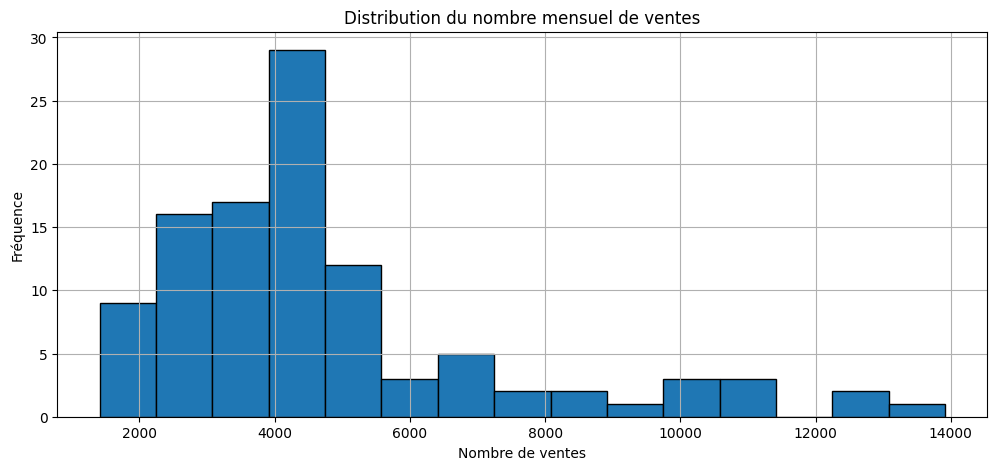

In [7]:
fig, ax = plt.subplots()
ax.hist(df["Sales"], bins=15, edgecolor="black")
ax.set_title("Distribution du nombre mensuel de ventes")
ax.set_xlabel("Nombre de ventes")
ax.set_ylabel("Fréquence")
plt.show()

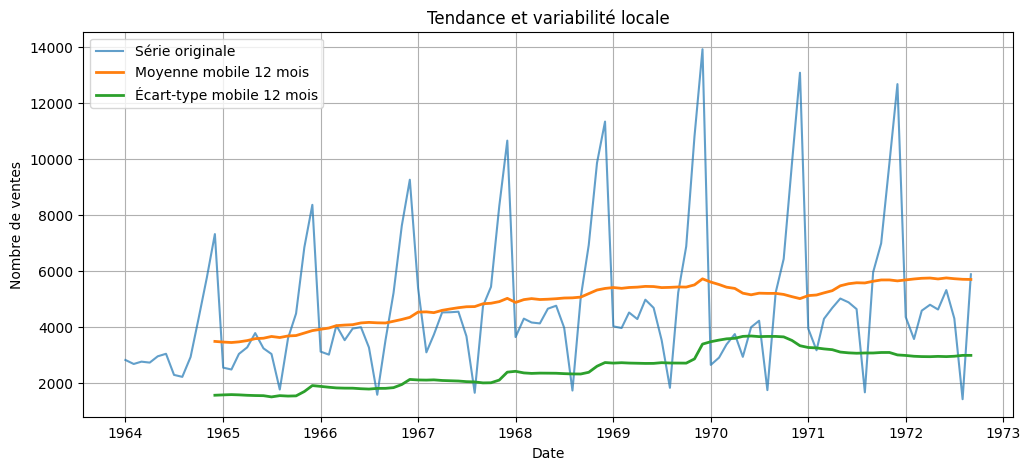

In [8]:
# Moyenne mobile pour visualiser la tendance locale
rolling_window = 12
rolling_mean = df["Sales"].rolling(window=rolling_window).mean()
rolling_std = df["Sales"].rolling(window=rolling_window).std()

fig, ax = plt.subplots()
ax.plot(df.index, df["Sales"], label="Série originale", alpha=0.7)
ax.plot(rolling_mean.index, rolling_mean, label="Moyenne mobile 12 mois", linewidth=2)
ax.plot(rolling_std.index, rolling_std, label="Écart-type mobile 12 mois", linewidth=2)
ax.set_title("Tendance et variabilité locale")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de ventes")
ax.legend()
plt.show()

### Interprétation graphique de la tendance et de la variabilité locale

La courbe bleue représente la série originale des ventes mensuelles de champagne. On observe des fluctuations importantes d'un mois à l'autre, avec des pics très marqués en fin d'année, notamment autour de novembre et décembre. Ces pics réguliers indiquent une forte saisonnalité annuelle, probablement liée aux fêtes de fin d'année où la consommation de champagne augmente fortement.

La courbe orange correspond à la moyenne mobile sur 12 mois. Elle permet de lisser les variations saisonnières et de mieux visualiser la tendance générale. On remarque une tendance globalement croissante entre 1964 et 1969, ce qui signifie que le niveau moyen des ventes augmente durant cette période. À partir de 1970, la tendance semble se stabiliser légèrement, avec une légère baisse puis une reprise progressive vers 1971-1972.

La courbe verte représente l'écart-type mobile sur 12 mois. Elle mesure la variabilité locale des ventes autour de leur moyenne. On constate que cette variabilité augmente progressivement jusqu'à environ 1969-1970, ce qui signifie que les écarts entre les mois faibles et les mois forts deviennent plus importants. Cette évolution montre que la variance n'est pas constante dans le temps.

Ainsi, cette visualisation met en évidence trois caractéristiques importantes de la série : une tendance non constante, une forte saisonnalité annuelle et une variabilité qui évolue avec le niveau des ventes. La série ne semble donc pas stationnaire. Une transformation logarithmique ou une différenciation pourra être nécessaire avant la modélisation ARIMA/SARIMA.


## 3. Décomposition de la série

Une série temporelle peut être décomposée en trois composantes :

- **Tendance** : évolution globale de long terme ;
- **Saisonnalité** : variations périodiques régulières ;
- **Résidu** : partie non expliquée par la tendance et la saisonnalité.

Deux modèles sont généralement utilisés :

### Modèle additif

$$
Y_t = T_t + S_t + R_t
$$

Il est adapté lorsque l'amplitude des variations saisonnières reste globalement stable.

### Modèle multiplicatif

$$
Y_t = T_t \times S_t \times R_t
$$

Il est adapté lorsque l'amplitude saisonnière augmente avec le niveau de la série.

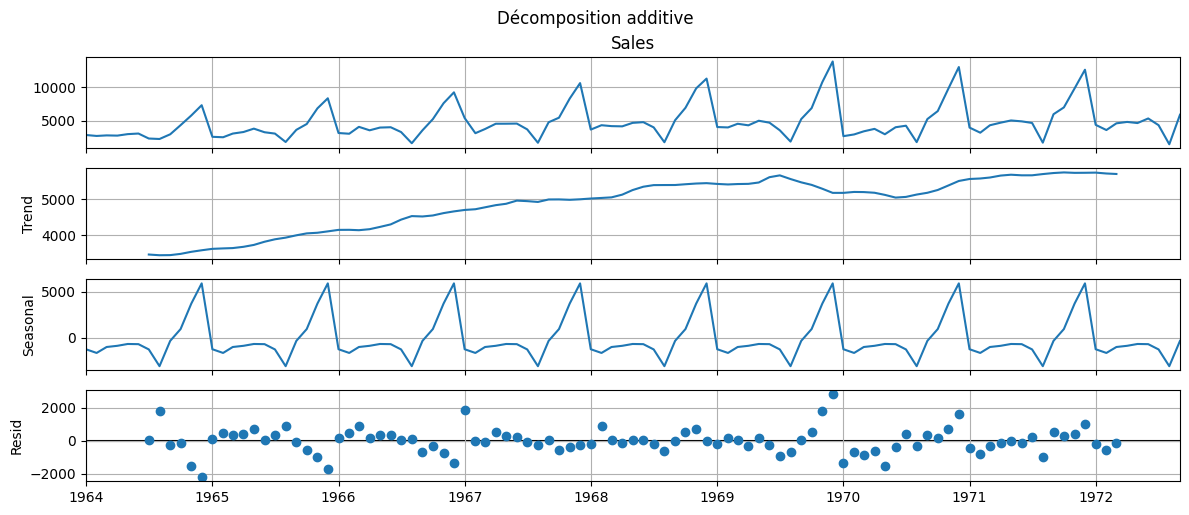

In [9]:
decomp_add = seasonal_decompose(df["Sales"], model="additive", period=12)
decomp_add.plot()
plt.suptitle("Décomposition additive", y=1.02)
plt.show()

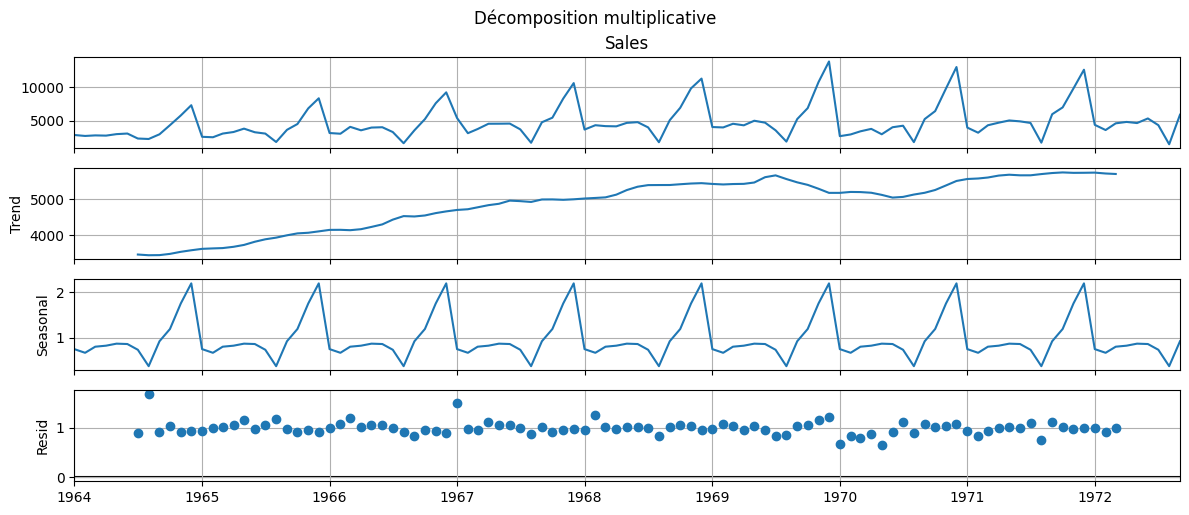

In [10]:
# La décomposition multiplicative exige des valeurs strictement positives.
decomp_mul = seasonal_decompose(df["Sales"], model="multiplicative", period=12)
decomp_mul.plot()
plt.suptitle("Décomposition multiplicative", y=1.02)
plt.show()

### Interprétation de la décomposition

La décomposition additive suppose que la série s'écrit sous la forme $Y_t = T_t + S_t + R_t$. Dans ce cas, la saisonnalité et les résidus sont exprimés dans la même unité que la série originale, c'est-à-dire en nombre de ventes. La composante saisonnière représente donc un volume de ventes ajouté ou retiré à la tendance. Les résidus peuvent être positifs ou négatifs, car ils correspondent à l'écart absolu entre la série observée et la somme tendance-saisonnalité.

La décomposition multiplicative suppose que la série s'écrit sous la forme $Y_t = T_t 	imes S_t 	imes R_t$. Ici, la saisonnalité et les résidus sont exprimés comme des coefficients multiplicatifs autour de 1. Une valeur saisonnière supérieure à 1 indique un mois où les ventes sont supérieures à la tendance, tandis qu'une valeur inférieure à 1 indique un mois où les ventes sont plus faibles que la tendance.

Dans cette série, la saisonnalité de fin d'année devient plus forte lorsque le niveau global des ventes augmente. Cela suggère que l'effet saisonnier est plutôt proportionnel au niveau de la série. La décomposition multiplicative est donc souvent plus cohérente pour ce dataset, même si les deux formes doivent être comparées avec les résidus et les performances finales des modèles.


## 4. Hypothèses initiales sur la dynamique

D'après les visualisations précédentes, on peut formuler les hypothèses suivantes :

1. La série semble probablement non stationnaire à cause d'une tendance non constante.
2. Une transformation logarithmique peut être utile, car la variabilité augmente avec le niveau des ventes.
3. Une différenciation simple et/ou saisonnière peut être nécessaire pour stabiliser la moyenne.
4. La saisonnalité annuelle est très marquée, avec une période de 12 mois.
5. Un modèle SARIMA peut être particulièrement pertinent, car il permet de modéliser à la fois la tendance, l'autocorrélation et la saisonnalité.


## 5. Feature engineering

Nous créons quelques variables explicatives utiles pour comprendre la série :

- année ;
- mois ;
- trimestre ;
- retards temporels ;
- moyennes mobiles.

Ces variables ne sont pas toutes utilisées directement dans ARIMA, mais elles aident à mieux analyser la dynamique.

In [11]:
features = df.copy()
features["year"] = features.index.year
features["month"] = features.index.month
features["quarter"] = features.index.quarter
features["lag_1"] = features["Sales"].shift(1)
features["lag_12"] = features["Sales"].shift(12)
features["rolling_mean_3"] = features["Sales"].rolling(window=3).mean()
features["rolling_mean_12"] = features["Sales"].rolling(window=12).mean()
features.head(15)

,Sales,year,month,quarter,lag_1,lag_12,rolling_mean_3,rolling_mean_12
Month,,,,,,,,
1964-01-01,2815,1964,1,1,NaN,NaN,NaN,NaN
1964-02-01,2672,1964,2,1,2815.0,NaN,NaN,NaN
1964-03-01,2755,1964,3,1,2672.0,NaN,2747.333333,NaN
1964-04-01,2721,1964,4,2,2755.0,NaN,2716.000000,NaN
1964-05-01,2946,1964,5,2,2721.0,NaN,2807.333333,NaN
1964-06-01,3036,1964,6,2,2946.0,NaN,2901.000000,NaN
1964-07-01,2282,1964,7,3,3036.0,NaN,2754.666667,NaN
1964-08-01,2212,1964,8,3,2282.0,NaN,2510.000000,NaN
1964-09-01,2922,1964,9,3,2212.0,NaN,2472.000000,NaN


In [12]:
monthly_profile = features.groupby("month")["Sales"].agg(["mean", "std", "min", "max"])
monthly_profile

,mean,std,min,max
month,,,,
1,3601.555556,928.318656,2541,5375
2,3235.000000,595.148931,2475,4292
3,3827.555556,651.778933,2755,4577
4,3958.333333,697.050393,2721,4788
5,4149.888889,801.736154,2927,5010
6,4265.888889,765.456962,3036,5312
7,3652.111111,727.459010,2282,4633
8,1726.777778,217.719302,1413,2212
9,4678.111111,1082.154153,2922,5951


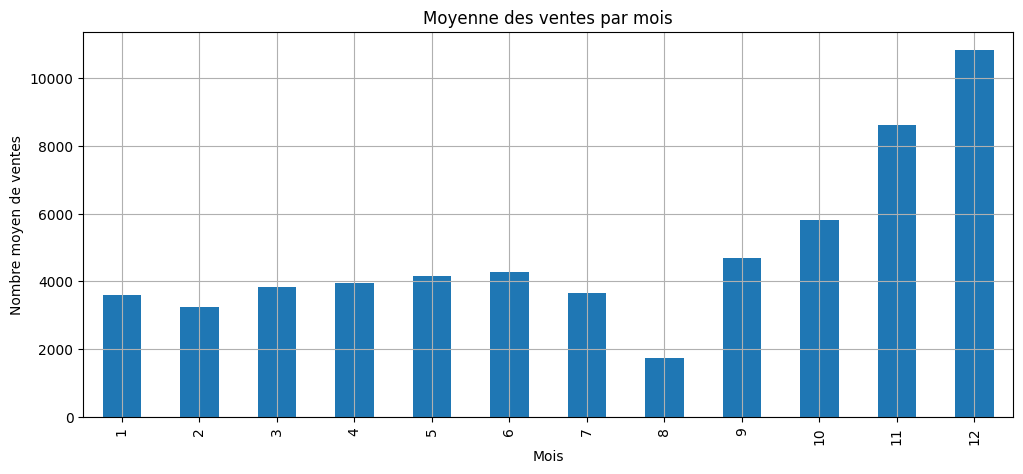

In [13]:
fig, ax = plt.subplots()
monthly_profile["mean"].plot(kind="bar", ax=ax)
ax.set_title("Moyenne des ventes par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre moyen de ventes")
plt.show()


## 6. Tests de stationnarité : ADF et KPSS

Une série est stationnaire si ses propriétés statistiques, comme la moyenne et la variance, restent stables dans le temps.

### Test ADF

Hypothèses :

$$
H_0 : \text{la série possède une racine unitaire, donc elle n'est pas stationnaire}
$$

$$
H_1 : \text{la série est stationnaire}
$$

Règle de décision : si la p-value est inférieure à 0.05, on rejette $H_0$.

### Test KPSS

Hypothèses :

$$
H_0 : \text{la série est stationnaire}
$$

$$
H_1 : \text{la série n'est pas stationnaire}
$$

Règle de décision : si la p-value est inférieure à 0.05, on rejette $H_0$.

Les deux tests sont complémentaires car leurs hypothèses nulles sont opposées.

In [14]:
def stationarity_tests(series, name="Série"):
    series = pd.Series(series).dropna()

    adf_result = adfuller(series, autolag="AIC")
    kpss_result = kpss(series, regression="c", nlags="auto")

    results = pd.DataFrame({
        "Test": ["ADF", "KPSS"],
        "Statistique": [adf_result[0], kpss_result[0]],
        "p-value": [adf_result[1], kpss_result[1]],
        "Conclusion à 5%": [
            "Stationnaire" if adf_result[1] < 0.05 else "Non stationnaire",
            "Non stationnaire" if kpss_result[1] < 0.05 else "Stationnaire"
        ]
    })
    print(f"Résultats des tests de stationnarité — {name}")
    return results

stationarity_tests(df["Sales"], "Série originale")

Résultats des tests de stationnarité — Série originale


,Test,Statistique,p-value,Conclusion à 5%
0,ADF,-1.833593,0.363916,Non stationnaire
1,KPSS,0.512672,0.038813,Non stationnaire


## 7. Transformations et différenciation

Pour stabiliser une série non stationnaire, on peut appliquer :

- une transformation logarithmique ;
- une transformation racine carrée ;
- une différenciation.

L'opérateur de retard $L$ est défini par :

$$
L Y_t = Y_{t-1}
$$

La différenciation d'ordre 1 est :

$$
\nabla Y_t = Y_t - Y_{t-1} = (1-L)Y_t
$$

La différenciation d'ordre $d$ est :

$$
\nabla^d Y_t = (1-L)^dY_t
$$

In [15]:
transformed = df.copy()
transformed["log"] = np.log(transformed["Sales"])
transformed["sqrt"] = np.sqrt(transformed["Sales"])
transformed["diff_1"] = transformed["Sales"].diff()
transformed["log_diff_1"] = transformed["log"].diff()
transformed["seasonal_diff_12"] = transformed["Sales"].diff(12)
transformed["diff_1_seasonal_12"] = transformed["Sales"].diff().diff(12)

transformed.head(15)

,Sales,log,sqrt,diff_1,log_diff_1,seasonal_diff_12,diff_1_seasonal_12
Month,,,,,,,
1964-01-01,2815,7.942718,53.056574,NaN,NaN,NaN,NaN
1964-02-01,2672,7.890583,51.691392,-143.0,-0.052135,NaN,NaN
1964-03-01,2755,7.921173,52.488094,83.0,0.030590,NaN,NaN
1964-04-01,2721,7.908755,52.163205,-34.0,-0.012418,NaN,NaN
1964-05-01,2946,7.988204,54.277067,225.0,0.079449,NaN,NaN
1964-06-01,3036,8.018296,55.099909,90.0,0.030093,NaN,NaN
1964-07-01,2282,7.732808,47.770284,-754.0,-0.285489,NaN,NaN
1964-08-01,2212,7.701652,47.031904,-70.0,-0.031155,NaN,NaN
1964-09-01,2922,7.980024,54.055527,710.0,0.278371,NaN,NaN


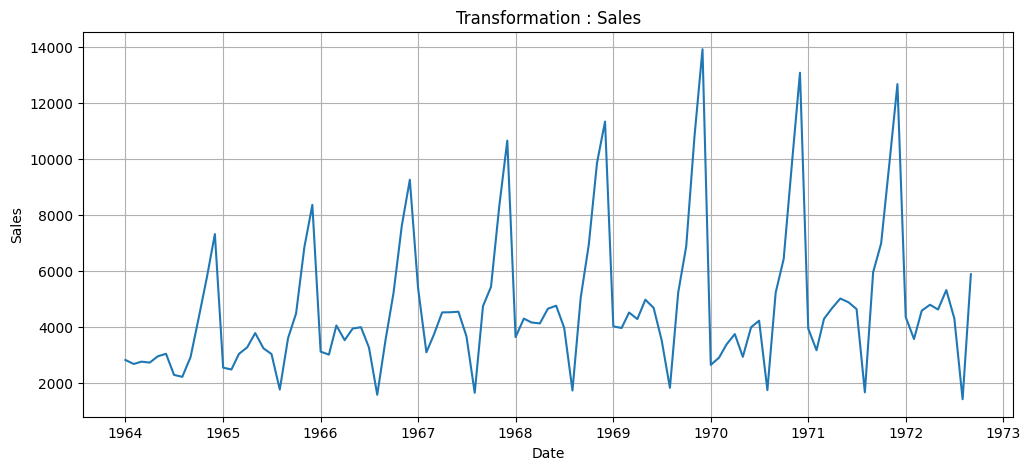

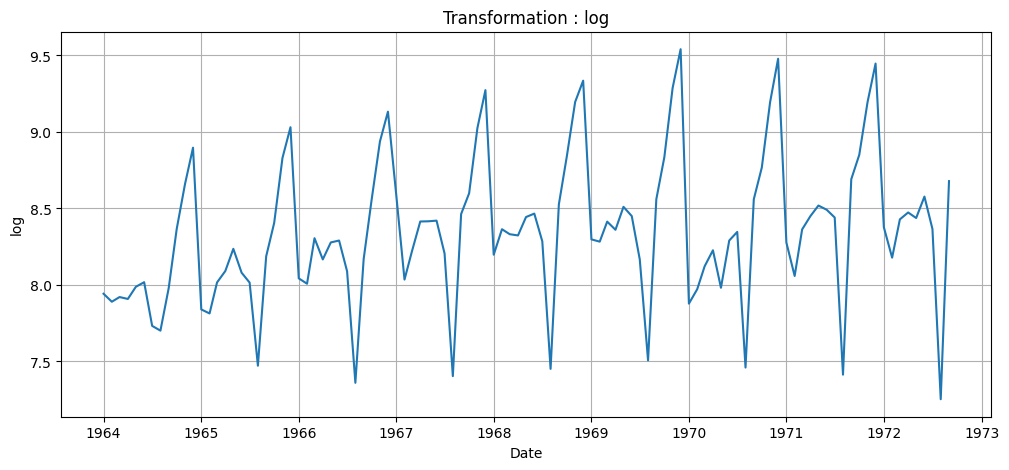

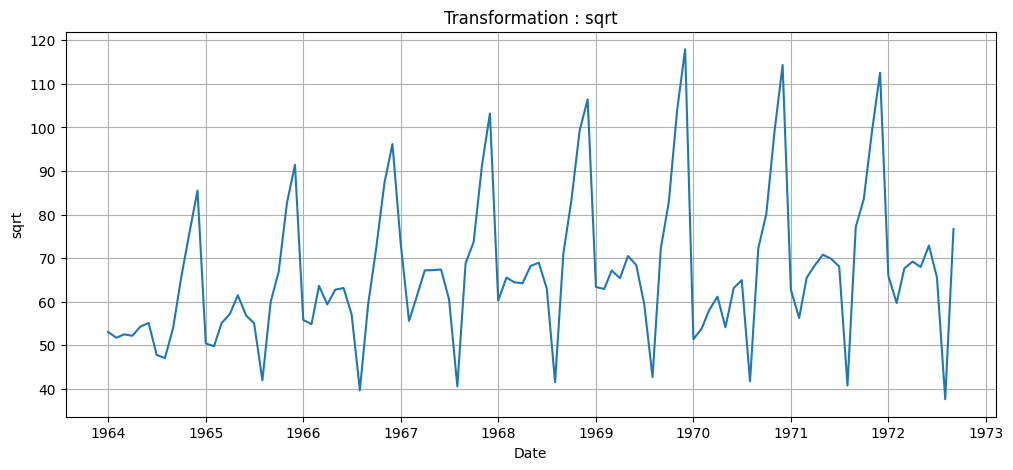

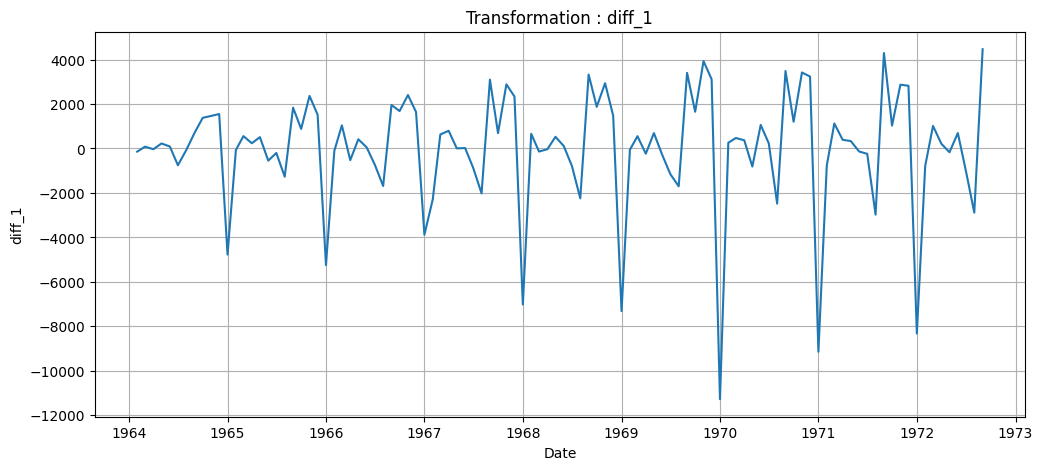

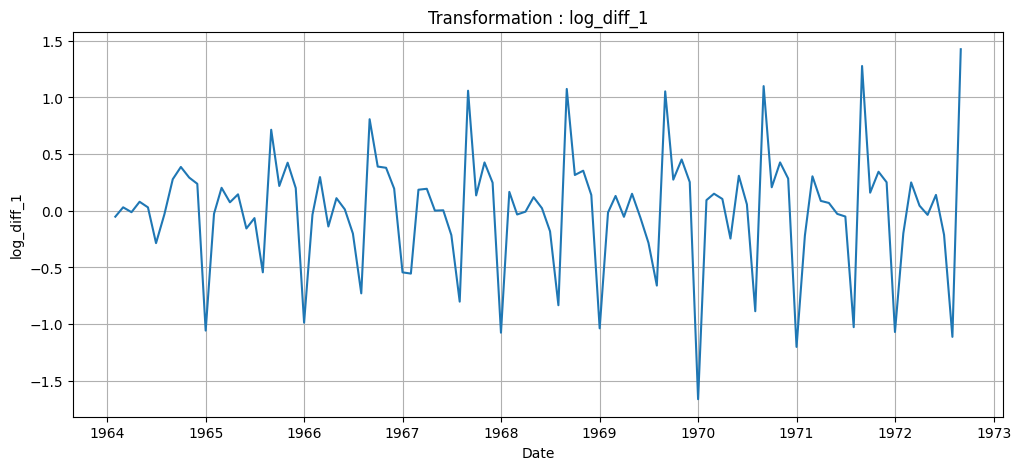

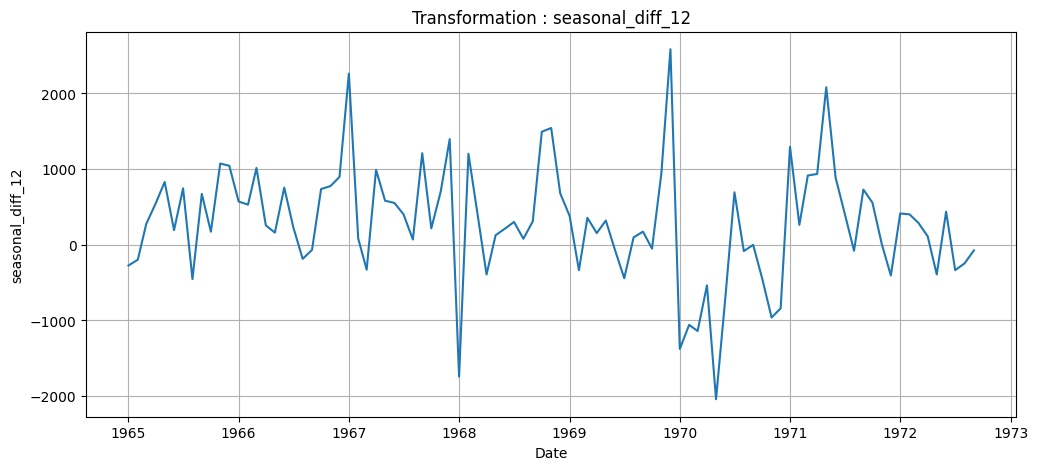

In [16]:
columns_to_plot = ["Sales", "log", "sqrt", "diff_1", "log_diff_1", "seasonal_diff_12"]

for col in columns_to_plot:
    fig, ax = plt.subplots()
    ax.plot(transformed.index, transformed[col])
    ax.set_title(f"Transformation : {col}")
    ax.set_xlabel("Date")
    ax.set_ylabel(col)
    plt.show()

In [17]:
for col in ["Sales", "log", "sqrt", "diff_1", "log_diff_1", "seasonal_diff_12", "diff_1_seasonal_12"]:
    display(stationarity_tests(transformed[col], col))

Résultats des tests de stationnarité — Sales


,Test,Statistique,p-value,Conclusion à 5%
0,ADF,-1.833593,0.363916,Non stationnaire
1,KPSS,0.512672,0.038813,Non stationnaire


Résultats des tests de stationnarité — log


,Test,Statistique,p-value,Conclusion à 5%
0,ADF,-2.255119,0.186852,Non stationnaire
1,KPSS,0.562789,0.027525,Non stationnaire


Résultats des tests de stationnarité — sqrt


...

C:\Users\ou2_s\AppData\Local\Temp\ipykernel_2696\1184829584.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


,Test,Statistique,p-value,Conclusion à 5%
0,ADF,-7.626619,2.060580e-11,Stationnaire
1,KPSS,0.294397,1.000000e-01,Stationnaire


Résultats des tests de stationnarité — diff_1_seasonal_12


C:\Users\ou2_s\AppData\Local\Temp\ipykernel_2696\1184829584.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


,Test,Statistique,p-value,Conclusion à 5%
0,ADF,-4.427713,0.000265,Stationnaire
1,KPSS,0.323083,0.100000,Stationnaire


### Interprétation attendue

Après transformation et différenciation, on cherche une série dont :

- la moyenne est plus stable ;
- la variance est moins dépendante du temps ;
- les tests ADF et KPSS donnent une conclusion favorable à la stationnarité.

Pour ce dataset, la transformation logarithmique est utile si la variance augmente avec le niveau des ventes. La différenciation d'ordre 1 traite la tendance, tandis que la différenciation saisonnière d'ordre 12 vise à retirer le motif annuel. Si une combinaison de différenciation simple et saisonnière rend la série stationnaire, cela soutient l'utilisation d'un modèle SARIMA avec $d=1$ et éventuellement $D=1$.


## 8. Analyse ACF/PACF

L'autocorrélation au retard $k$ mesure la relation entre $Y_t$ et $Y_{t-k}$ :

$$
\rho(k) = \frac{Cov(Y_t, Y_{t-k})}{Var(Y_t)}
$$

La PACF mesure l'autocorrélation partielle entre $Y_t$ et $Y_{t-k}$ après suppression de l'effet des retards intermédiaires.

Règles pratiques :

- ACF qui coupe rapidement et PACF qui décroît : modèle MA possible ;
- PACF qui coupe rapidement et ACF qui décroît : modèle AR possible ;
- ACF et PACF qui décroissent progressivement : modèle ARMA possible ;
- pics aux multiples de 12 : saisonnalité possible.

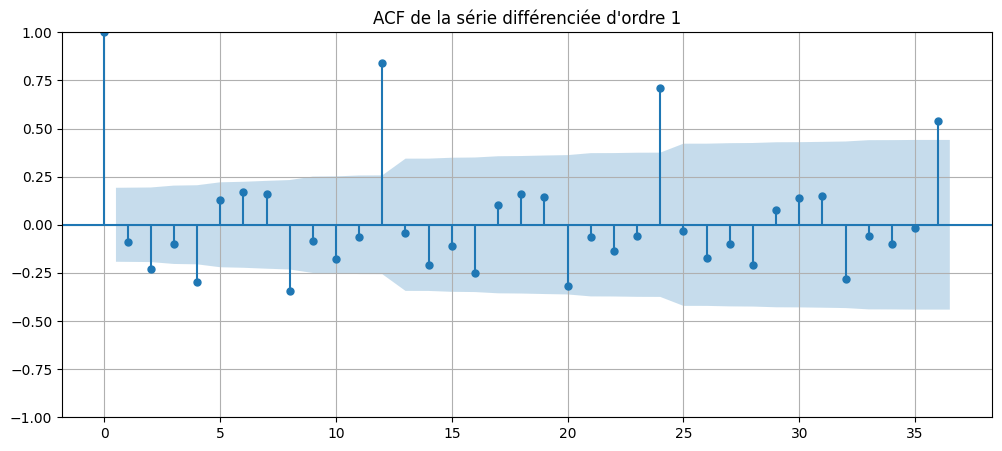

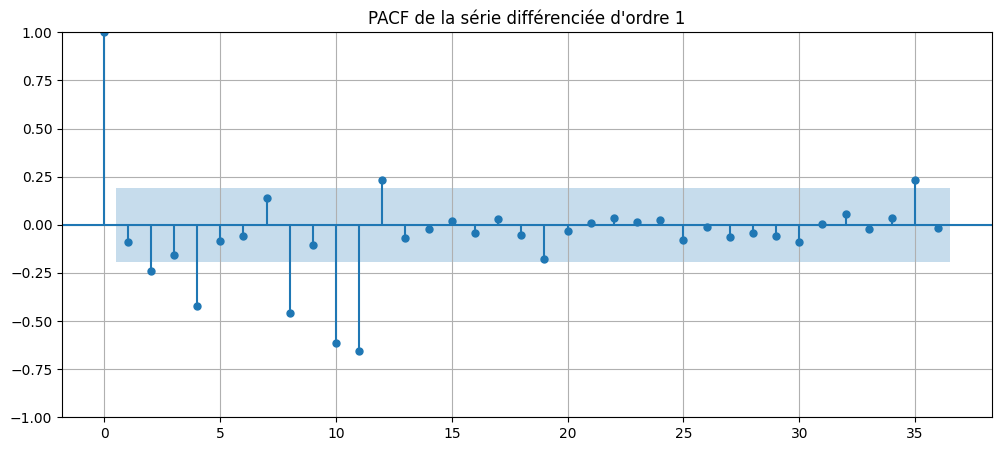

In [18]:
series_for_acf = transformed["diff_1"].dropna()

fig, ax = plt.subplots()
plot_acf(series_for_acf, lags=36, ax=ax)
ax.set_title("ACF de la série différenciée d'ordre 1")
plt.show()

fig, ax = plt.subplots()
plot_pacf(series_for_acf, lags=36, ax=ax, method="ywm")
ax.set_title("PACF de la série différenciée d'ordre 1")
plt.show()

### Hypothèses sur les ordres $p$ et $q$

À partir des graphiques ACF/PACF, on peut proposer plusieurs modèles candidats, par exemple :

- ARIMA(1,1,0) ;
- ARIMA(0,1,1) ;
- ARIMA(1,1,1) ;
- ARIMA(2,1,1) ;
- ARIMA(1,1,2).

Ces choix seront ensuite validés par les performances, AIC/BIC et diagnostic des résidus.

## 9. Découpage chronologique train/test

Pour une série temporelle, il ne faut pas mélanger aléatoirement les données. Le modèle doit être entraîné sur le passé et évalué sur le futur.

Nous utilisons ici environ 80 % des observations pour l'entraînement et 20 % pour le test.

Taille train : 84
Taille test  : 21
Période train: 1964-01-01 → 1970-12-01
Période test : 1971-01-01 → 1972-09-01


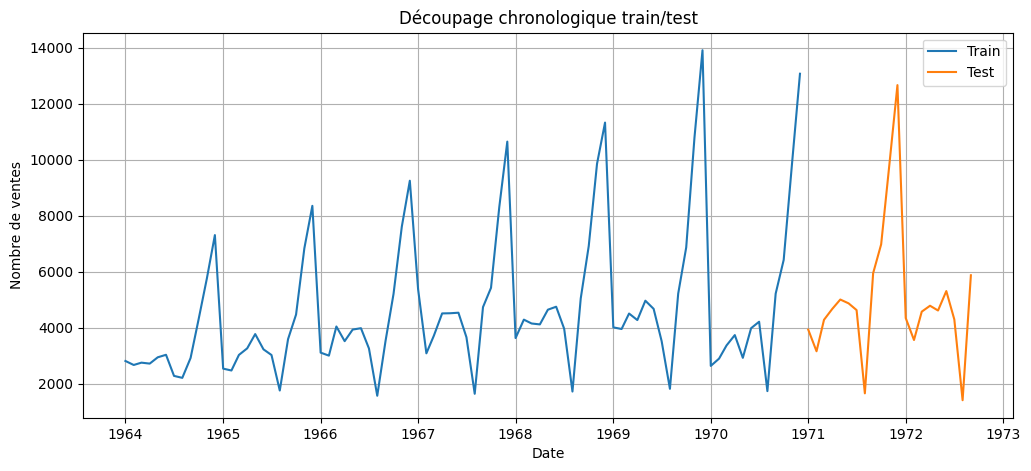

In [19]:
train_size = int(len(df) * 0.8)
train = df["Sales"].iloc[:train_size]
test = df["Sales"].iloc[train_size:]

print("Taille train :", len(train))
print("Taille test  :", len(test))
print("Période train:", train.index.min().date(), "→", train.index.max().date())
print("Période test :", test.index.min().date(), "→", test.index.max().date())

fig, ax = plt.subplots()
ax.plot(train.index, train, label="Train")
ax.plot(test.index, test, label="Test")
ax.set_title("Découpage chronologique train/test")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de ventes")
ax.legend()
plt.show()


## 10. Fonctions d'évaluation sans librairies avancées

Nous calculons manuellement les métriques avec `numpy`.

### MSE

$$
MSE = \frac{1}{n}\sum_{t=1}^{n}(Y_t - \hat{Y}_t)^2
$$

### RMSE

$$
RMSE = \sqrt{MSE}
$$

### MAE

$$
MAE = \frac{1}{n}\sum_{t=1}^{n}|Y_t - \hat{Y}_t|
$$

Dans ce projet, ces erreurs s'interprètent en nombre de ventes mensuelles.


In [20]:
def mse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def evaluate_model(y_true, y_pred, model_name, aic=np.nan, bic=np.nan):
    return {
        "Modèle": model_name,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MSE": mse(y_true, y_pred),
        "AIC": aic,
        "BIC": bic
    }

## 11. Modèles de référence : naïf et moyenne mobile

Avant d'utiliser ARIMA, il faut comparer avec des modèles simples.

### Modèle naïf

La prévision du prochain mois est égale à la dernière valeur observée :

$$
\hat{Y}_{t+1}=Y_t
$$

### Moyenne mobile

La prévision est la moyenne des $k$ dernières observations :

$$
\hat{Y}_{t+1}=\frac{1}{k}\sum_{i=0}^{k-1}Y_{t-i}
$$

Un modèle avancé doit battre ces références pour être réellement utile.

In [21]:
def naive_forecast(train, test):
    history = list(train.values)
    predictions = []
    for actual in test.values:
        pred = history[-1]
        predictions.append(pred)
        history.append(actual)
    return np.array(predictions)

def moving_average_forecast(train, test, window=3):
    history = list(train.values)
    predictions = []
    for actual in test.values:
        pred = np.mean(history[-window:])
        predictions.append(pred)
        history.append(actual)
    return np.array(predictions)

pred_naive = naive_forecast(train, test)
pred_ma3 = moving_average_forecast(train, test, window=3)
pred_ma12 = moving_average_forecast(train, test, window=12)

baseline_results = [
    evaluate_model(test.values, pred_naive, "Naïf"),
    evaluate_model(test.values, pred_ma3, "Moyenne mobile 3 mois"),
    evaluate_model(test.values, pred_ma12, "Moyenne mobile 12 mois")
]

pd.DataFrame(baseline_results)

,Modèle,MAE,RMSE,MSE,AIC,BIC
0,Naïf,2175.285714,3316.743533,1.100079e+07,NaN,NaN
1,Moyenne mobile 3 mois,2648.555556,3317.921340,1.100860e+07,NaN,NaN
2,Moyenne mobile 12 mois,1711.817460,2403.313301,5.775915e+06,NaN,NaN


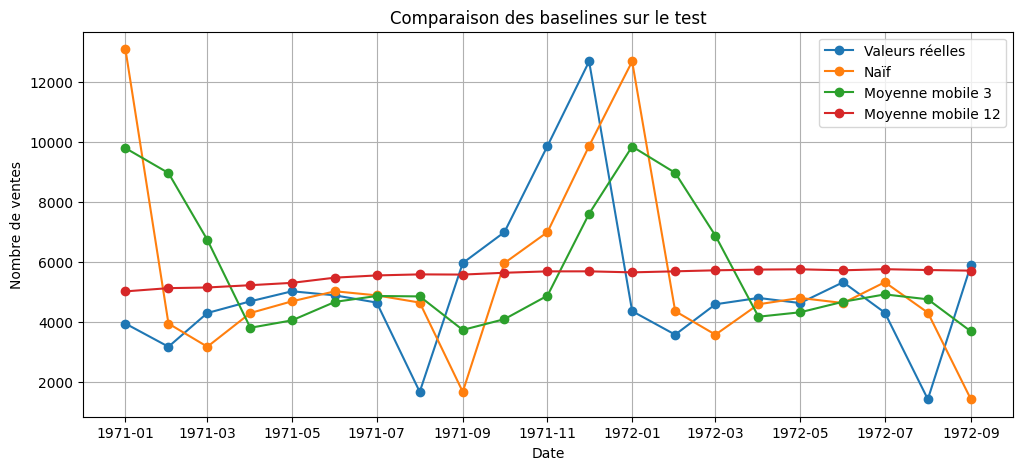

In [22]:
fig, ax = plt.subplots()
ax.plot(test.index, test.values, marker="o", label="Valeurs réelles")
ax.plot(test.index, pred_naive, marker="o", label="Naïf")
ax.plot(test.index, pred_ma3, marker="o", label="Moyenne mobile 3")
ax.plot(test.index, pred_ma12, marker="o", label="Moyenne mobile 12")
ax.set_title("Comparaison des baselines sur le test")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de ventes")
ax.legend()
plt.show()


## 12. Walk-forward validation

La validation walk-forward simule une prévision réaliste :

1. entraîner le modèle sur les données disponibles ;
2. prédire la prochaine valeur ;
3. observer la vraie valeur ;
4. l'ajouter à l'historique ;
5. répéter.

Cela réduit le risque de fuite de données, car le futur n'est jamais utilisé pour prédire le passé.

In [23]:
def walk_forward_arima(train, test, order):
    history = list(train.values)
    predictions = []
    for actual in test.values:
        model = ARIMA(history, order=order)
        fitted = model.fit()
        forecast = fitted.forecast(steps=1)[0]
        predictions.append(forecast)
        history.append(actual)
    return np.array(predictions)

## 13. Théorie : AR, MA et ARMA

### Modèle AR(p)

Un modèle autorégressif AR(p) explique la valeur actuelle par ses valeurs passées :

$$
Y_t = c + \phi_1Y_{t-1}+\phi_2Y_{t-2}+...+\phi_pY_{t-p}+\varepsilon_t
$$

En opérateur de retard :

$$
\Phi(L)Y_t = c + \varepsilon_t
$$

avec :

$$
\Phi(L)=1-\phi_1L-...-\phi_pL^p
$$

La stationnarité exige que les racines du polynôme $\Phi(z)=0$ soient à l'extérieur du cercle unité.

### Modèle MA(q)

Un modèle MA(q) explique la valeur actuelle par les erreurs passées :

$$
Y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1}+...+\theta_q\varepsilon_{t-q}
$$

En opérateur de retard :

$$
Y_t = \mu + \Theta(L)\varepsilon_t
$$

avec :

$$
\Theta(L)=1+\theta_1L+...+\theta_qL^q
$$

L'inversibilité exige que les racines du polynôme $\Theta(z)=0$ soient à l'extérieur du cercle unité.

### Modèle ARMA(p,q)

ARMA combine les deux mécanismes :

$$
\Phi(L)Y_t = c + \Theta(L)\varepsilon_t
$$

## 14. Implémentation from scratch : AR(p) par OLS

Pour un modèle AR(p), on peut écrire :

$$
Y_t = c + \phi_1Y_{t-1}+...+\phi_pY_{t-p}+\varepsilon_t
$$

On construit une matrice de design $X$ contenant une constante et les retards de la série. L'estimation par moindres carrés ordinaires est :

$$
\hat{\beta} = (X'X)^{-1}X'Y
$$

Cette partie montre le mécanisme interne d'estimation d'un modèle AR.

In [24]:
def fit_ar_ols(series, p):
    y = np.asarray(series, dtype=float)
    X, target = [], []
    for t in range(p, len(y)):
        X.append([1.0] + [y[t-i] for i in range(1, p+1)])
        target.append(y[t])
    X = np.asarray(X)
    target = np.asarray(target)
    beta = np.linalg.inv(X.T @ X) @ X.T @ target
    return beta

def predict_ar_one_step(history, beta):
    p = len(beta) - 1
    x = np.array([1.0] + [history[-i] for i in range(1, p+1)])
    return float(x @ beta)

def walk_forward_ar_ols(train, test, p):
    history = list(train.values)
    predictions = []
    for actual in test.values:
        beta = fit_ar_ols(history, p=p)
        pred = predict_ar_one_step(history, beta)
        predictions.append(pred)
        history.append(actual)
    return np.array(predictions)

# Comme AR exige une série stationnaire, on l'applique à la série différenciée puis on reconstruit les niveaux.
def walk_forward_ar_ols_on_diff(train, test, p):
    history_levels = list(train.values)
    predictions_levels = []

    for actual in test.values:
        diff_history = np.diff(history_levels)
        beta = fit_ar_ols(diff_history, p=p)
        pred_diff = predict_ar_one_step(list(diff_history), beta)
        pred_level = history_levels[-1] + pred_diff
        predictions_levels.append(pred_level)
        history_levels.append(actual)

    return np.array(predictions_levels)

pred_ar1_scratch = walk_forward_ar_ols_on_diff(train, test, p=1)
pred_ar2_scratch = walk_forward_ar_ols_on_diff(train, test, p=2)

pd.DataFrame([
    evaluate_model(test.values, pred_ar1_scratch, "AR(1) from scratch sur diff"),
    evaluate_model(test.values, pred_ar2_scratch, "AR(2) from scratch sur diff")
])

,Modèle,MAE,RMSE,MSE,AIC,BIC
0,AR(1) from scratch sur diff,2266.094456,3333.219449,1.111035e+07,NaN,NaN
1,AR(2) from scratch sur diff,2164.679978,3180.990141,1.011870e+07,NaN,NaN


## 15. Implémentation simplifiée from scratch : MA(q) et ARMA(p,q)

L'estimation exacte des modèles MA et ARMA est plus complexe que celle d'un modèle AR, car les erreurs passées ne sont pas directement observées.

Principe simplifié :

1. initialiser les résidus à zéro ;
2. prédire la série avec les paramètres courants ;
3. recalculer les résidus ;
4. chercher les paramètres qui minimisent la somme des carrés des erreurs.

La cellule suivante donne une version pédagogique basée sur une optimisation numérique simple.

In [25]:
from scipy.optimize import minimize

def arma_sse(params, y, p=1, q=1):
    y = np.asarray(y, dtype=float)
    c = params[0]
    phi = params[1:1+p]
    theta = params[1+p:1+p+q]
    errors = np.zeros(len(y))
    preds = np.zeros(len(y))

    start = max(p, q)
    for t in range(start, len(y)):
        ar_part = sum(phi[i-1] * y[t-i] for i in range(1, p+1))
        ma_part = sum(theta[j-1] * errors[t-j] for j in range(1, q+1))
        preds[t] = c + ar_part + ma_part
        errors[t] = y[t] - preds[t]

    return np.sum(errors[start:] ** 2)

def fit_arma_scratch(series, p=1, q=1):
    y = np.asarray(series, dtype=float)
    initial_params = np.zeros(1 + p + q)
    initial_params[0] = np.mean(y)
    result = minimize(arma_sse, initial_params, args=(y, p, q), method="Nelder-Mead")
    return result.x, result.fun

# Démonstration sur la série différenciée d'entraînement
params_arma11, sse_arma11 = fit_arma_scratch(np.diff(train.values), p=1, q=1)
params_arma11, sse_arma11

(array([47.71785584,  0.63607034, -1.15352271]),
 np.float64(326448666.59622705))

### Comparaison avec une librairie

Nous comparons les paramètres estimés de façon simplifiée avec ceux de `statsmodels`. Les valeurs ne seront pas forcément identiques, car `statsmodels` utilise des méthodes plus robustes, notamment le maximum de vraisemblance.

In [26]:
sm_arma11 = ARIMA(np.diff(train.values), order=(1, 0, 1)).fit()
print(sm_arma11.summary())
print("Paramètres from scratch ARMA(1,1) sur diff :", params_arma11)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   83
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -755.862
Date:                Tue, 05 May 2026   AIC                           1519.724
Time:                        19:22:21   BIC                           1529.399
Sample:                             0   HQIC                          1523.611
                                 - 83                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.9345     20.902      2.054      0.040       1.968      83.901
ar.L1          0.5117      0.080      6.381      0.000       0.355       0.669
ma.L1         -1.0000      0.135     -7.387      0.0

## 16. Modèles ARIMA avec statsmodels

Un modèle ARIMA(p,d,q) combine :

- $p$ : nombre de retards autorégressifs ;
- $d$ : nombre de différenciations ;
- $q$ : nombre de retards des erreurs.

Formellement :

$$
\Phi(L)(1-L)^dY_t = c + \Theta(L)\varepsilon_t
$$

Nous testons plusieurs combinaisons et nous comparons les modèles par AIC, BIC, MAE, RMSE et MSE.

Pour garder le notebook rapide à exécuter, les modèles candidats sont évalués ici avec une prévision directe sur l'horizon de test. La fonction de walk-forward est fournie plus haut et peut être utilisée pour une évaluation plus stricte sur un modèle sélectionné.

In [27]:
arima_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
]

arima_results = []
arima_predictions = {}

for order in arima_orders:
    try:
        fitted_on_train = ARIMA(train, order=order).fit(method_kwargs={"maxiter": 50})
        preds = fitted_on_train.forecast(steps=len(test))
        name = f"ARIMA{order}"
        arima_predictions[name] = np.asarray(preds)
        arima_results.append(evaluate_model(test.values, preds, name, fitted_on_train.aic, fitted_on_train.bic))
    except Exception as e:
        print(f"Erreur pour ARIMA{order}: {e}")

pd.DataFrame(arima_results).sort_values("RMSE")


,Modèle,MAE,RMSE,MSE,AIC,BIC
3,"ARIMA(2, 1, 1)",2034.301224,2748.743798,7.555592e+06,1518.167962,1527.843325
2,"ARIMA(1, 1, 1)",2368.785588,3018.734201,9.112756e+06,1521.933849,1529.190371
1,"ARIMA(0, 1, 1)",7797.889193,8157.844692,6.655043e+07,1534.011216,1538.848898
0,"ARIMA(1, 1, 0)",7893.946045,8249.686961,6.805733e+07,1533.997487,1538.835169


## 17. Recherche automatique simple par AIC/BIC

Nous pouvons tester une grille de valeurs pour $p$, $d$ et $q$.

Attention : le meilleur AIC/BIC sur l'entraînement n'est pas toujours le meilleur modèle sur le test. Il faut donc combiner les critères statistiques, les erreurs de prévision et le diagnostic des résidus.

In [28]:
grid_results = []

# Grille volontairement limitée pour garder le notebook rapide et lisible.
# Vous pouvez l'élargir après validation du notebook.
candidate_orders = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (0, 2, 1),
]

for order in candidate_orders:
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit(method_kwargs={"maxiter": 50})
        grid_results.append({
            "order": order,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })
    except Exception:
        continue

grid_df = pd.DataFrame(grid_results).sort_values("AIC")
grid_df.head(10)


,order,AIC,BIC
3,"(2, 1, 1)",1518.167962,1527.843325
4,"(0, 2, 1)",1520.093299,1524.906738
2,"(1, 1, 1)",1521.933849,1529.190371
1,"(1, 1, 0)",1533.997487,1538.835169
0,"(0, 1, 1)",1534.011216,1538.848898


## 18. Variante saisonnière : SARIMA

Si la série présente une structure saisonnière, on peut utiliser SARIMA :

$$
SARIMA(p,d,q)(P,D,Q,s)
$$

Pour une série mensuelle, la période saisonnière est généralement :

$$
s = 12
$$

Nous testons quelques configurations simples.

In [29]:
sarima_configs = [
    ((1, 1, 1), (0, 1, 1, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 0, 12)),
    ((1, 1, 1), (1, 0, 0, 12)),
]

sarima_results = []
sarima_predictions = {}

for order, seasonal_order in sarima_configs:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=50)
        preds = fitted.forecast(steps=len(test))
        name = f"SARIMA{order}x{seasonal_order}"
        sarima_predictions[name] = np.asarray(preds)
        sarima_results.append(evaluate_model(test.values, preds, name, fitted.aic, fitted.bic))
    except Exception as e:
        print(f"Erreur pour SARIMA{order}x{seasonal_order}: {e}")

pd.DataFrame(sarima_results).sort_values("RMSE")


,Modèle,MAE,RMSE,MSE,AIC,BIC
2,"SARIMA(1, 1, 0)x(1, 1, 0, 12)",845.432402,983.590795,9.674509e+05,963.845964,970.027293
0,"SARIMA(1, 1, 1)x(0, 1, 1, 12)",947.291292,1112.118848,1.236808e+06,934.892233,943.064438
1,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",1106.512879,1274.024348,1.623138e+06,933.812563,939.941717
3,"SARIMA(1, 1, 1)x(1, 0, 0, 12)",1806.698783,2009.896077,4.039682e+06,1133.038120,1142.032101


## 19. Tableau comparatif global

Nous regroupons les performances des baselines, des modèles from scratch, des modèles ARIMA et des modèles SARIMA.

In [30]:
all_results = []
all_results.extend(baseline_results)
all_results.append(evaluate_model(test.values, pred_ar1_scratch, "AR(1) from scratch sur diff"))
all_results.append(evaluate_model(test.values, pred_ar2_scratch, "AR(2) from scratch sur diff"))
all_results.extend(arima_results)
all_results.extend(sarima_results)

results_df = pd.DataFrame(all_results).sort_values("RMSE").reset_index(drop=True)
results_df

,Modèle,MAE,RMSE,MSE,AIC,BIC
0,"SARIMA(1, 1, 0)x(1, 1, 0, 12)",845.432402,983.590795,9.674509e+05,963.845964,970.027293
1,"SARIMA(1, 1, 1)x(0, 1, 1, 12)",947.291292,1112.118848,1.236808e+06,934.892233,943.064438
2,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",1106.512879,1274.024348,1.623138e+06,933.812563,939.941717
3,"SARIMA(1, 1, 1)x(1, 0, 0, 12)",1806.698783,2009.896077,4.039682e+06,1133.038120,1142.032101
4,Moyenne mobile 12 mois,1711.817460,2403.313301,5.775915e+06,NaN,NaN
5,"ARIMA(2, 1, 1)",2034.301224,2748.743798,7.555592e+06,1518.167962,1527.843325
6,"ARIMA(1, 1, 1)",2368.785588,3018.734201,9.112756e+06,1521.933849,1529.190371
7,AR(2) from scratch sur diff,2164.679978,3180.990141,1.011870e+07,NaN,NaN
8,Naïf,2175.285714,3316.743533,1.100079e+07,NaN,NaN
9,Moyenne mobile 3 mois,2648.555556,3317.921340,1.100860e+07,NaN,NaN


In [31]:
best_model_name = results_df.iloc[0]["Modèle"]
best_model_name

'SARIMA(1, 1, 0)x(1, 1, 0, 12)'

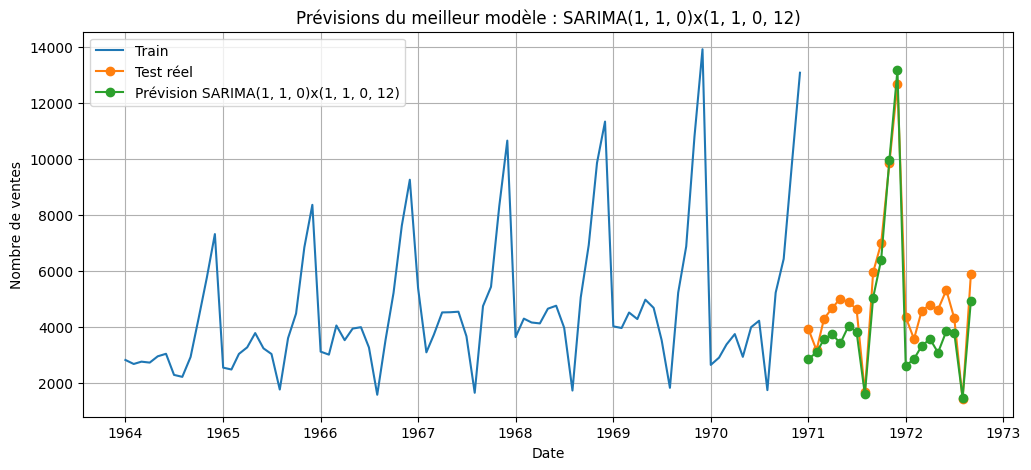

In [32]:
# Récupération des prédictions du meilleur modèle pour visualisation
prediction_dict = {
    "Naïf": pred_naive,
    "Moyenne mobile 3 mois": pred_ma3,
    "Moyenne mobile 12 mois": pred_ma12,
    "AR(1) from scratch sur diff": pred_ar1_scratch,
    "AR(2) from scratch sur diff": pred_ar2_scratch,
}
prediction_dict.update(arima_predictions)
prediction_dict.update(sarima_predictions)

best_preds = prediction_dict[best_model_name]

fig, ax = plt.subplots()
ax.plot(train.index, train.values, label="Train")
ax.plot(test.index, test.values, marker="o", label="Test réel")
ax.plot(test.index, best_preds, marker="o", label=f"Prévision {best_model_name}")
ax.set_title(f"Prévisions du meilleur modèle : {best_model_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de ventes")
ax.legend()
plt.show()


### Interprétation du tableau

À commenter dans le rapport :

- quel modèle obtient la plus faible RMSE ;
- quel modèle obtient la plus faible MAE ;
- si le modèle avancé améliore réellement les baselines ;
- si le gain est important ou faible ;
- si un modèle légèrement moins performant mais plus simple peut être préférable.

## 20. Diagnostic des résidus du modèle retenu

Un bon modèle doit produire des résidus proches d'un bruit blanc :

- moyenne proche de zéro ;
- absence d'autocorrélation ;
- variance relativement stable ;
- distribution raisonnablement symétrique.

Nous ajustons le modèle retenu sur l'ensemble train, puis nous analysons ses résidus.

In [33]:
def fit_model_from_name(model_name, train):
    if model_name.startswith("ARIMA"):
        order = eval(model_name.replace("ARIMA", ""))
        return ARIMA(train, order=order).fit(method_kwargs={"maxiter": 50})
    elif model_name.startswith("SARIMA"):
        # Extraction simple du texte : SARIMA(order)x(seasonal_order)
        left, right = model_name.replace("SARIMA", "").split("x")
        order = eval(left)
        seasonal_order = eval(right)
        return SARIMAX(train, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=50)
    else:
        # Si le meilleur est une baseline, on choisit le meilleur ARIMA disponible pour le diagnostic statistique.
        best_arima_row = pd.DataFrame(arima_results).sort_values("RMSE").iloc[0]
        order = eval(best_arima_row["Modèle"].replace("ARIMA", ""))
        print("Le meilleur modèle global est une baseline. Diagnostic effectué sur", best_arima_row["Modèle"])
        return ARIMA(train, order=order).fit(method_kwargs={"maxiter": 50})

fitted_final = fit_model_from_name(best_model_name, train)
residuals = pd.Series(fitted_final.resid).dropna()

print(fitted_final.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   84
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -478.923
Date:                            Tue, 05 May 2026   AIC                            963.846
Time:                                    19:22:22   BIC                            970.027
Sample:                                01-01-1964   HQIC                           966.254
                                     - 12-01-1970                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3464      0.097     -3.554      0.000      -0.537      -0.155
ar.S.L12      -0.3216      0.116   

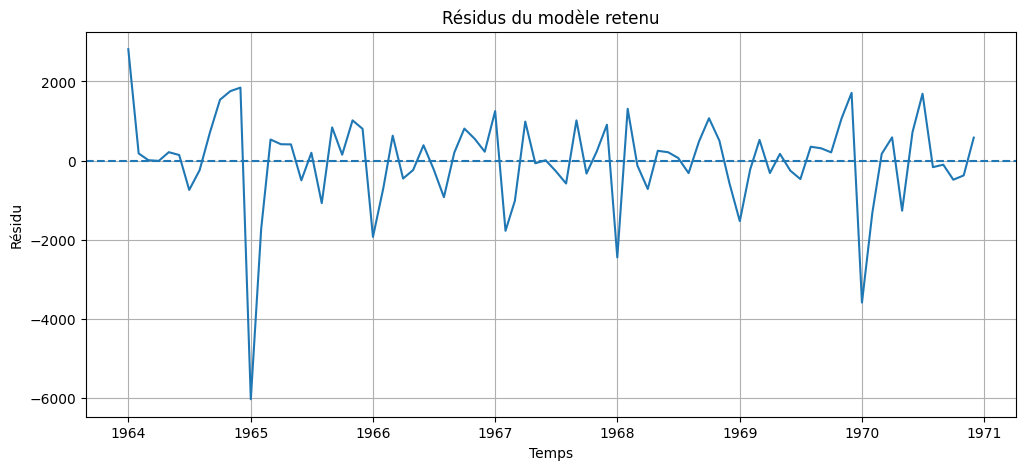

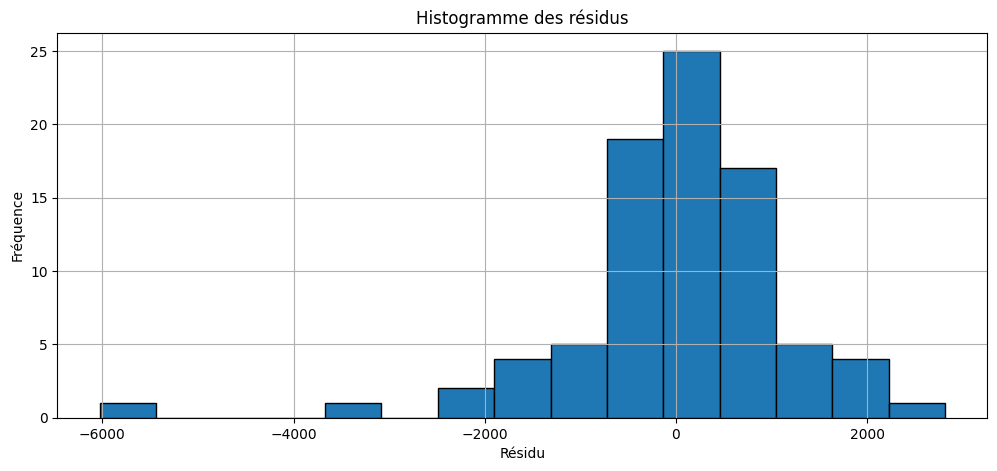

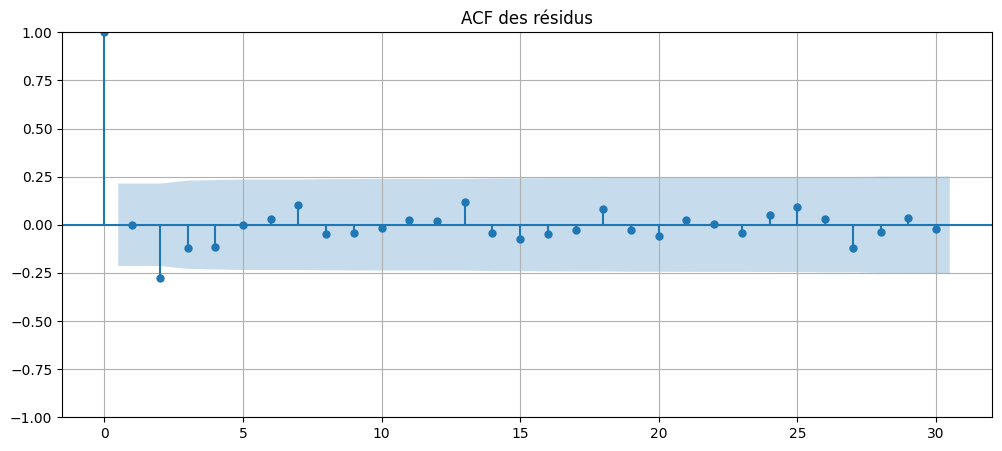

In [34]:
fig, ax = plt.subplots()
ax.plot(residuals.index if hasattr(residuals, "index") else range(len(residuals)), residuals)
ax.axhline(0, linestyle="--")
ax.set_title("Résidus du modèle retenu")
ax.set_xlabel("Temps")
ax.set_ylabel("Résidu")
plt.show()

fig, ax = plt.subplots()
ax.hist(residuals, bins=15, edgecolor="black")
ax.set_title("Histogramme des résidus")
ax.set_xlabel("Résidu")
ax.set_ylabel("Fréquence")
plt.show()

fig, ax = plt.subplots()
plot_acf(residuals, lags=30, ax=ax)
ax.set_title("ACF des résidus")
plt.show()

### Test de Ljung-Box

Le test de Ljung-Box vérifie si les résidus sont autocorrélés.

Hypothèses :

$$
H_0 : \text{les résidus ne sont pas autocorrélés}
$$

$$
H_1 : \text{les résidus sont autocorrélés}
$$

Si la p-value est supérieure à 0.05, on ne rejette pas $H_0$, ce qui est favorable.

In [35]:
ljung = acorr_ljungbox(residuals, lags=[6, 12, 18, 24], return_df=True)
ljung

,lb_stat,lb_pvalue
6,9.198930,0.162696
12,10.706660,0.554211
18,13.962733,0.731517
24,15.085592,0.918229


### Normalité et homoscédasticité

Nous utilisons :

- le test de Shapiro-Wilk pour la normalité ;
- un test ARCH pour vérifier une éventuelle hétéroscédasticité conditionnelle.

Ces tests ne sont pas toujours parfaits sur des séries courtes, donc ils doivent être interprétés avec prudence et en complément des graphiques.

In [36]:
normality_stat, normality_p = shapiro(residuals)
arch_stat, arch_p, _, _ = het_arch(residuals)

pd.DataFrame({
    "Test": ["Shapiro-Wilk normalité", "ARCH homoscédasticité"],
    "Statistique": [normality_stat, arch_stat],
    "p-value": [normality_p, arch_p],
    "Interprétation à 5%": [
        "Normalité non rejetée" if normality_p > 0.05 else "Normalité rejetée",
        "Homoscédasticité non rejetée" if arch_p > 0.05 else "Hétéroscédasticité possible"
    ]
})

,Test,Statistique,p-value,Interprétation à 5%
0,Shapiro-Wilk normalité,0.869652,4.726949e-07,Normalité rejetée
1,ARCH homoscédasticité,2.533133,9.903840e-01,Homoscédasticité non rejetée


## 21. Sélection et justification du modèle final

Le modèle final doit être choisi en combinant :

- la performance sur le test ;
- les critères AIC/BIC ;
- l'analyse des résidus ;
- la simplicité ;
- l'interprétabilité.

Un modèle très complexe avec un faible gain peut ne pas être préférable à un modèle plus simple.

In [37]:
print("Modèle retenu selon la RMSE :", best_model_name)
print("Performances associées :")
display(results_df.iloc[[0]])

baseline_rmse = results_df.loc[results_df["Modèle"] == "Naïf", "RMSE"].iloc[0]
best_rmse = results_df.iloc[0]["RMSE"]
gain = (baseline_rmse - best_rmse) / baseline_rmse * 100
print(f"Gain relatif de RMSE par rapport au modèle naïf : {gain:.2f}%")

Modèle retenu selon la RMSE : SARIMA(1, 1, 0)x(1, 1, 0, 12)
Performances associées :


,Modèle,MAE,RMSE,MSE,AIC,BIC
0,"SARIMA(1, 1, 0)x(1, 1, 0, 12)",845.432402,983.590795,967450.851979,963.845964,970.027293


Gain relatif de RMSE par rapport au modèle naïf : 70.34%


## 22. Conclusion 

Dans le contexte des ventes mensuelles de champagne en France, l'analyse de série temporelle permet de comprendre la dynamique des ventes et de produire des prévisions utiles pour la planification commerciale.

Les principaux points à retenir sont :

1. La série présente une saisonnalité annuelle très marquée, avec des pics en fin d'année.
2. La tendance n'est pas constante : les ventes augmentent globalement jusqu'à la fin des années 1960, puis se stabilisent partiellement.
3. La variance semble évoluer avec le niveau de la série, ce qui rend la transformation logarithmique pertinente.
4. Les tests ADF et KPSS permettent de vérifier formellement la stationnarité après transformation ou différenciation.
5. Les baselines sont indispensables pour juger la valeur réelle d'un modèle ARIMA/SARIMA.
6. Le modèle retenu doit être justifié par les performances, les critères statistiques et le diagnostic des résidus.

### Limites

- Le modèle utilise uniquement l'historique des ventes.
- Il n'intègre pas de variables externes comme les promotions, les prix, la production, les fêtes, la conjoncture économique ou les changements de distribution.
- Les prévisions peuvent être sensibles aux changements structurels du marché.



## 23. Résumé

La série mensuelle des ventes de champagne en France a été analysée selon une démarche complète de séries temporelles. L'analyse exploratoire a permis d'identifier une forte saisonnalité annuelle, notamment avec des pics en fin d'année, ainsi qu'une tendance non constante. L'évolution de la variabilité suggère que la série n'est pas strictement stationnaire et qu'une transformation logarithmique ou une différenciation peut être nécessaire.

Les tests ADF et KPSS ont été utilisés pour vérifier la stationnarité de la série originale et des séries transformées. Des modèles de référence, comme le modèle naïf et la moyenne mobile, ont d'abord été construits afin de disposer d'un point de comparaison. Ensuite, plusieurs modèles ARIMA et SARIMA ont été testés. Les modèles ont été comparés avec MAE, RMSE, MSE, AIC et BIC. Le modèle final a été sélectionné en tenant compte à la fois de la performance prédictive, de la simplicité et du diagnostic des résidus.

Cette démarche montre que la modélisation ARIMA/SARIMA peut capturer une partie importante de la dynamique des ventes mensuelles de champagne, en particulier lorsque la saisonnalité annuelle est correctement prise en compte. Les limites principales viennent de l'absence de variables explicatives externes et de la taille relativement courte de la série.
